In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import os
import re
import cv2
import pickle
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization, Activation, Add, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D, Flatten, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall
from collections import Counter

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Ruta
path_pokemon = '/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/pokemonDB_dataset.csv'

# Carga de datos
df = pd.read_csv(path_pokemon)

In [4]:
# Dividir los tipos múltiples en listas
listas_de_tipos = df['Type'].str.split(',')

conteo_tipos = Counter()

for lista in listas_de_tipos:
        # Creamos una lista limpia para cada Pokémon
        tipos_limpios = []
        for tipo in lista:
            # .strip() elimina espacios en blanco al inicio o final
            # ej. " Ice" -> "Ice"
            tipos_limpios.append(tipo.strip())

        # Actualizamos el conteo con los tipos limpios
        conteo_tipos.update(tipos_limpios)

print("--- Conteo Total de Pokémon por Tipo ---")
print("(Basado en la columna 'Type' dividida)\n")

# .most_common() ya nos da la lista ordenada de mayor a menor
for tipo, conteo in conteo_tipos.most_common():
    print(f"{tipo}: {conteo}")

print("\n-------------------------------------")
print(f"Total de tipos únicos encontrados: {len(conteo_tipos)}")

--- Conteo Total de Pokémon por Tipo ---
(Basado en la columna 'Type' dividida)

Water: 176
Normal: 153
Grass: 146
Psychic: 134
Flying: 132
Bug: 100
Fire: 97
Poison: 96
Dragon: 93
Fighting: 92
Ground: 90
Dark: 89
Rock: 88
Ghost: 87
Electric: 87
Steel: 85
Fairy: 74
Ice: 65

-------------------------------------
Total de tipos únicos encontrados: 18


In [5]:
def normalize_name(name):
    """
    Limpia un nombre de Pokémon para que coincida
    entre el CSV y los nombres de las carpetas.
    """
    if not isinstance(name, str):
        name = str(name)


    # 2. Quitar paréntesis y espacios
    #    (Hacemos esto primero para limpiar formatos)
    name = name.replace("(", "").replace(")", "")

    # 3. Reemplazar caracteres especiales
    name = name.replace('♀', '-f')       # Nidoran♀ -> nidoran-f
    name = name.replace('♂', '-m')       # Nidoran♂ -> nidoran-m
    name = name.replace("'", "")       # Farfetch'd -> farfetchd
    name = name.replace(".", "")       # Mime Jr. -> mimejr
    name = name.replace("_", "-")      # Farfetch_d -> farfetch-d

    return name

print("Creando mapa de etiquetas normalizado...")

label_map = {}

for index, row in df.iterrows():

    # Obtener el nombre "sucio" del CSV
    nombre_pokemon_csv = row['Pokemon']

    # Manejar los casos especiales de Nidoran

    if "Nidoran♀ (female)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♀"
    elif "Nidoran♂ (male)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♂"
    else:
        # Si no es un caso especial, usar el nombre tal cual
        nombre_a_normalizar = nombre_pokemon_csv

    # 1. Normalizar el nombre (ya sea el original o el pre-limpiado)
    nombre_normalizado = normalize_name(nombre_a_normalizar)

    # 2. Obtener los tipos
    tipos_str = row['Type']
    lista_de_tipos = [tipo.strip() for tipo in tipos_str.split(',')]

    # 3. Guardar en el mapa con la clave normalizada
    if nombre_normalizado not in label_map:
        label_map[nombre_normalizado] = lista_de_tipos
    else:
        pass

print(f"--- Mapa de Etiquetas Creado. {len(label_map)} entradas únicas. ---")

# (Opcional) Verifica que los nombres clave se normalizaron bien
print("\nEjemplo del mapa (normalizado):")
print(f"'nidoran-f': {label_map.get('nidoran-f')}")
print(f"'nidoran-m': {label_map.get('nidoran-m')}")
print(f"'aegislashbladeforme': {label_map.get('aegislashbladeforme')}")
print(f"'farfetchd': {label_map.get('farfetchd')}")
print(f"'mimejr': {label_map.get('mimejr')}")

Creando mapa de etiquetas normalizado...
--- Mapa de Etiquetas Creado. 1215 entradas únicas. ---

Ejemplo del mapa (normalizado):
'nidoran-f': None
'nidoran-m': None
'aegislashbladeforme': None
'farfetchd': None
'mimejr': None


In [6]:
if not os.path.exists("/content/pokemon1"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Images DB.zip" "/content/pokemon1.zip"
  print("¡Copia finalizada!")
  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon1.zip -d /content/pokemon1
  print("¡Dataset listo en /content/pokemon1!")
else:
  print("El dataset ya está en /content/pokemon1")

if not os.path.exists("/content/pokemon2"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Dataset.zip" "/content/pokemon2.zip"
  print("¡Copia finalizada!")

  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon2.zip -d /content/pokemon2
  print("¡Dataset listo en /content/pokemon2!")
else:
  print("El dataset ya está en /content/pokemon2")

if not os.path.exists("/content/pokemon3"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Fotos Pokemon1.zip" "/content/pokemon3.zip"
  print("¡Copia finalizada!")

  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon3.zip -d /content/pokemon3
  print("¡Dataset listo en /content/pokemon3!")
else:
  print("El dataset ya está en /content/pokemon3")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon1!
Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon2!
Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon3!


In [7]:
carpeta_raiz = '/content/pokemon1'
X_rutas_imagenes = []
y_etiquetas = []

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# Busqueda de imagenes en otra ruta
# --- Celda 2b: Explorar y AÑADIR desde la segunda carpeta ---

carpeta_raiz_nueva = r'/content/pokemon2'

print(f"\nIniciando exploración de la segunda fuente de datos: {carpeta_raiz_nueva}...")
imagenes_encontradas_antes = len(X_rutas_imagenes)

# Usamos os.walk para explorar la nueva ruta
for root, dirs, files in os.walk(carpeta_raiz_nueva):

    # 2. Filtrar: Buscamos carpetas que sean 'normal' y no 'shiny'
    #    Usamos .lower() para encontrar 'normal' o 'Normal'
    if os.path.sep + 'normal' in root.lower() and 'shiny' not in root.lower():

        # 3. Extraer el nombre del Pokémon
        try:
            partes_ruta = root.split(os.path.sep)

            # La carpeta 'normal' es la de [version]
            # La ruta es: ...\[nombrepokemon]\[generacion]\[juego]\[version]
            # Por lo tanto, el nombre está 3 niveles "arriba" de 'normal'

            # Encontramos el índice de la carpeta 'normal' (o 'Normal')
            idx_normal = -1
            for i, parte in enumerate(partes_ruta):
                if parte.lower() == 'normal':
                    idx_normal = i
                    break

            if idx_normal != -1 and idx_normal >= 3:
                # Extraemos el nombre: [idx_normal - 3]
                nombre_pokemon_folder = partes_ruta[idx_normal - 3]

                # 4. Normalizar el nombre (¡usando la misma función!)
                nombre_normalizado = normalize_name(nombre_pokemon_folder)

                # 5. Buscar en el mapa y añadir
                if nombre_normalizado in label_map:
                    for file_name in files:
                        # Nos aseguramos de tomar solo PNGs/JPGs (NO GIFs)
                        if file_name.endswith(('.png', '.jpg', '.jpeg')):
                            ruta_completa = os.path.join(root, file_name)
                            X_rutas_imagenes.append(ruta_completa)
                            y_etiquetas.append(label_map[nombre_normalizado])
                else:
                    # (Nos avisará si este nombre de carpeta no está en el CSV)
                    print(f"Advertencia (Fuente 2): Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada.")

        except Exception as e:
            print(f"Error procesando ruta {root}: {e}")

print("\n" + "-"*60)
print("Exploración de la segunda fuente de datos completada.")

carpeta_raiz = '/content/pokemon3'

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")


Iniciando exploración.
Advertencia: Carpeta 'Pokemon Images DB' (normalizado a 'Pokemon Images DB') no encontrada en el CSV.
Advertencia: Carpeta 'Kyurem (White Kyurem)' (normalizado a 'Kyurem White Kyurem') no encontrada en el CSV.
Advertencia: Carpeta 'Greninja (Ash-Greninja)' (normalizado a 'Greninja Ash-Greninja') no encontrada en el CSV.
Advertencia: Carpeta 'Rotom (Wash Rotom)' (normalizado a 'Rotom Wash Rotom') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Dusk Mane Necrozma)' (normalizado a 'Necrozma Dusk Mane Necrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Unbound)' (normalizado a 'Hoopa Hoopa Unbound') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Ultra Necrozma)' (normalizado a 'Necrozma Ultra Necrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Confined)' (normalizado a 'Hoopa Hoopa Confined') no encontrada en el CSV.
Advertencia: Carpeta 'Galarian Farfetch_d' (normalizado a 'Galarian Farfetch-d') no encontrada

In [8]:
print("Iniciando binarización de las 15,032 etiquetas...")

mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y_etiquetas)

classes = mlb.classes_
num_classes = len(classes)

print("\n--- Binarizador de Etiquetas Creado ---")
print(f"Número total de clases (tipos) únicas: {num_classes}")
print(f"Clases encontradas: {classes}")

with open('mlb_binarizer.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("\nBinarizador guardado como 'mlb_binarizer.pkl'")

print("\nDividiendo los 15,032 items en Train/Validation...")

X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_rutas_imagenes,
    y_binarized,
    test_size=0.2,
    random_state=42
)

print("\n--- Datos Divididos (Nuevos Totales) ---")
print(f"Imágenes de Entrenamiento (X_train_paths): {len(X_train_paths)}")
print(f"Etiquetas de Entrenamiento (y_train):     {len(y_train)}")
print(f"Imágenes de Validación (X_val_paths):   {len(X_val_paths)}")
print(f"Etiquetas de Validación (y_val):       {len(y_val)}")

Iniciando binarización de las 15,032 etiquetas...

--- Binarizador de Etiquetas Creado ---
Número total de clases (tipos) únicas: 18
Clases encontradas: ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']

Binarizador guardado como 'mlb_binarizer.pkl'

Dividiendo los 15,032 items en Train/Validation...

--- Datos Divididos (Nuevos Totales) ---
Imágenes de Entrenamiento (X_train_paths): 12025
Etiquetas de Entrenamiento (y_train):     12025
Imágenes de Validación (X_val_paths):   3007
Etiquetas de Validación (y_val):       3007


--- Análisis de Desbalance (Umbral = 1100) ---
Se encontraron 12 clases raras:
  -> Bug: 1084 muestras
  -> Dark: 686 muestras
  -> Dragon: 648 muestras
  -> Electric: 746 muestras
  -> Fairy: 617 muestras
  -> Fighting: 749 muestras
  -> Fire: 939 muestras
  -> Ghost: 566 muestras
  -> Ground: 1016 muestras
  -> Ice: 582 muestras
  -> Rock: 897 muestras
  -> Steel: 678 muestras


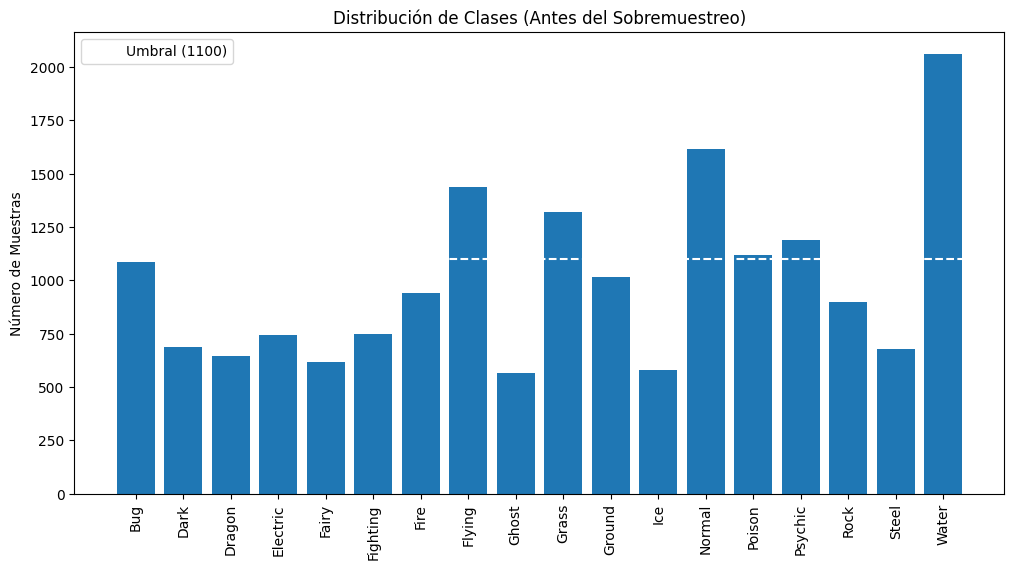

In [9]:
# --- 1. Calcular los conteos de cada clase ---
# y_train tiene forma (N, 18). Sumamos verticalmente (axis=0).
class_counts = np.sum(y_train, axis=0)

# --- 2. Definir tu umbral ---
UMBRAL = 1100

# --- 3. Encontrar las clases raras ---
# np.where nos da los índices (0 a 17) de las clases bajo el umbral
rare_class_indices = np.where(class_counts < UMBRAL)[0]
rare_class_names = [classes[i] for i in rare_class_indices]
rare_class_counts = class_counts[rare_class_indices]

print(f"--- Análisis de Desbalance (Umbral = {UMBRAL}) ---")
if len(rare_class_indices) > 0:
    print(f"Se encontraron {len(rare_class_indices)} clases raras:")
    for name, count in zip(rare_class_names, rare_class_counts):
        print(f"  -> {name}: {count} muestras")
else:
    print("¡No se encontraron clases por debajo del umbral! Tus datos están balanceados.")

# --- (Opcional) Graficar el desbalance ---
plt.figure(figsize=(12, 6))
plt.bar(classes, class_counts)
plt.axhline(y=UMBRAL, color='w', linestyle='--', label=f'Umbral ({UMBRAL})')
plt.xticks(rotation=90)
plt.title('Distribución de Clases (Antes del Sobremuestreo)')
plt.ylabel('Número de Muestras')
plt.legend()
plt.show()

In [10]:
# Listas para guardar las muestras que vamos a duplicar
paths_to_add = []
labels_to_add = []

print("Buscando muestras de clases raras para duplicar...")

# Iteramos sobre CADA imagen y etiqueta en el set de entrenamiento
for i in range(len(X_train_paths)):
    label_vector = y_train[i] # El array one-hot, ej: [0, 1, 0, ..., 1]

    # Comprobamos si esta etiqueta contiene ALGUNA de las clases raras
    for rare_index in rare_class_indices:
        if label_vector[rare_index] == 1:
            # ¡Encontrada! Añadimos esta muestra a nuestra lista de duplicados
            paths_to_add.append(X_train_paths[i])
            labels_to_add.append(y_train[i])

            # Importante: rompemos el bucle para no añadir la misma
            # imagen varias veces si tiene MÚLTIPLES tipos raros
            break

print(f"Se duplicarán {len(paths_to_add)} imágenes que contienen clases raras.")

Buscando muestras de clases raras para duplicar...
Se duplicarán 7480 imágenes que contienen clases raras.


In [11]:
# 1. Combinar las rutas (las listas de Python se suman)
X_train_balanced_paths = X_train_paths + paths_to_add

# 2. Combinar las etiquetas (los arrays de NumPy se concatenan)
# Convertimos 'labels_to_add' a un array de NumPy primero
y_train_balanced = np.concatenate((y_train, np.array(labels_to_add)), axis=0)

print(f"--- Dataset Balanceado Creado ---")
print(f"Tamaño original de entrenamiento: {len(X_train_paths)}")
print(f"Nuevo tamaño de entrenamiento:    {len(X_train_balanced_paths)}")

# (Opcional) Verificamos los nuevos conteos
new_class_counts = np.sum(y_train_balanced, axis=0)
print("\nNuevos conteos de clases raras:")
for name, old_count, new_count in zip(rare_class_names, rare_class_counts, new_class_counts[rare_class_indices]):
    print(f"  -> {name}: {old_count} -> {new_count}")

--- Dataset Balanceado Creado ---
Tamaño original de entrenamiento: 12025
Nuevo tamaño de entrenamiento:    19505

Nuevos conteos de clases raras:
  -> Bug: 1084 -> 2168
  -> Dark: 686 -> 1372
  -> Dragon: 648 -> 1296
  -> Electric: 746 -> 1492
  -> Fairy: 617 -> 1234
  -> Fighting: 749 -> 1498
  -> Fire: 939 -> 1878
  -> Ghost: 566 -> 1132
  -> Ground: 1016 -> 2032
  -> Ice: 582 -> 1164
  -> Rock: 897 -> 1794
  -> Steel: 678 -> 1356


In [12]:
IMG_SIZE = 64
NUM_CLASSES = 18
BATCH_SIZE = 16

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE = tf.data.AUTOTUNE

# --- Pipeline de Entrenamiento (MODIFICADO) ---
train_ds = tf.data.Dataset.from_tensor_slices((X_train_balanced_paths, y_train_balanced))
train_ds = train_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=True),
    num_parallel_calls=AUTOTUNE
)
# Asegúrate de barajar usando el nuevo tamaño total
train_ds = train_ds.shuffle(buffer_size=len(X_train_balanced_paths))
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# --- Pipeline de Validación (SIN CAMBIOS) ---
val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
val_ds = val_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=False),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Pipelines de Entrenamiento (¡Balanceado!) y Validación creados.")

NameError: in user code:

    File "/tmp/ipython-input-1895292341.py", line 11, in None  *
        lambda x, y: load_and_preprocess(x, y, augment=True)

    NameError: name 'load_and_preprocess' is not defined


In [ ]:
IMG_SIZE = 64
NUM_CLASSES = 18
BATCH_SIZE = 16

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, augment=False):
    """
    Carga una imagen desde la ruta, la decodifica, redimensiona
    y aplica aumento si se especifica.
    """
    try:
        image = tf.io.read_file(path)
        # expand_animations=False es crucial para manejar GIFs estáticos como JPGs
        image = tf.io.decode_image(image, channels=3, expand_animations=False)
        # Aseguramos que la forma sea conocida
        image.set_shape([None, None, 3])
    except Exception as e:
        print(f"Error decodificando imagen: {path}")
        # Retorna una imagen negra en caso de error
        image = tf.zeros([IMG_SIZE, IMG_SIZE, 3])

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    if augment:
        # Aumento de datos
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

        # Recorte aleatorio (Zoom ligero)
        # Obtenemos la altura y anchura (64x64)
        h, w, _ = image.shape
        # Calculamos un recorte del 85%
        crop_h = tf.cast(tf.cast(h, tf.float32) * 0.85, tf.int32)
        crop_w = tf.cast(tf.cast(w, tf.float32) * 0.85, tf.int32)

        # Aseguramos que el recorte no sea más grande que la imagen
        crop_h = tf.minimum(crop_h, h)
        crop_w = tf.minimum(crop_w, w)

        image = tf.image.random_crop(image, size=[crop_h, crop_w, 3])
        # Redimensionamos de vuelta al tamaño original
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Normalizar la imagen al rango [0, 1]
    image = image / 255.0

    return image, label

print("Función 'load_and_preprocess' definida.")

In [ ]:
try:
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_balanced_paths, y_train_balanced))

    train_ds = train_ds.map(
        lambda x, y: load_and_preprocess(x, y, augment=True), # Aplicamos aumento al entrenar
        num_parallel_calls=AUTOTUNE
    )

    # Barajamos usando el nuevo tamaño total
    train_ds = train_ds.shuffle(buffer_size=len(X_train_balanced_paths))
    train_ds = train_ds.batch(BATCH_SIZE)
    train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

    print("\n--- Pipeline de Entrenamiento (train_ds) Creado ---")
    print(f"   -> Usando {len(X_train_balanced_paths)} muestras (¡Balanceado!)")
    print(f"   -> {train_ds}")

    # --- Pipeline de Validación (SIN CAMBIOS) ---
    # Usa los datos de validación originales (sin balancear)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
    val_ds = val_ds.map(
        lambda x, y: load_and_preprocess(x, y, augment=False), # Sin aumento al validar
        num_parallel_calls=AUTOTUNE
    )
    val_ds = val_ds.batch(BATCH_SIZE)
    val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

    print("\n--- Pipeline de Validación (val_ds) Creado ---")
    print(f"   -> Usando {len(X_val_paths)} muestras (Original)")
    print(f"   -> {val_ds}")

    print("\n✅ Pipelines listos para el entrenamiento.")

except NameError as e:
    print(f"\nError: Una de las variables necesarias no fue definida.")
    print(f"Asegúrate de haber ejecutado las celdas [1] a [27] primero.")
    print(f"Detalle del error: {e}")
except Exception as e:
    print(f"Se produjo un error inesperado al crear los pipelines: {e}")

In [ ]:
print("\nMostrando 9 ejemplos del pipeline de entrenamiento (con aumento)...")

plt.figure(figsize=(12, 12))

# Tomamos un 'batch' (lote) del pipeline de entrenamiento
for images, labels in train_ds.take(1): # Tomamos solo 1 lote
    for i in range(9):
        if i >= len(images): # No mostrar más imágenes si el lote es más pequeño
            break

        ax = plt.subplot(3, 3, i + 1)

        # Mostramos la imagen (que ya está normalizada y aumentada)
        plt.imshow(images[i].numpy())

        # Obtenemos los nombres de las clases para esta imagen
        label_vector = labels[i].numpy()
        tipos_pokemon = [classes[idx] for idx, val in enumerate(label_vector) if val == 1]

        plt.title(", ".join(tipos_pokemon), fontsize=10)
        plt.axis("off")

plt.suptitle("Ejemplos de Imágenes del Pipeline 'train_ds' (Con Aumento)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el supertítulo
plt.savefig("aumento_inteligente_ejemplos.png")
print("Imagen de ejemplos guardada como 'aumento_inteligente_ejemplos.png'")
plt.show()

In [ ]:
def identity_block(X, f, filters, stage, block):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base   = 'bn'  + str(stage) + block + '_branch'
    F1, F2, F3 = filters
    X_shortcut = X

    X = Conv2D(filters=F1, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2a', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F2, kernel_size=(f, f), strides=(1, 1), padding='same', name=conv_name_base + '2b', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F3, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2c', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2c')(X)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def convolutional_block(X, f, filters, stage, block, s=2):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base   = 'bn'  + str(stage) + block + '_branch'
    F1, F2, F3 = filters
    X_shortcut = X

    # MAIN PATH
    X = Conv2D(filters=F1, kernel_size=(1, 1), strides=(s, s), padding='valid', name=conv_name_base + '2a', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F2, kernel_size=(f, f), strides=(1, 1), padding='same', name=conv_name_base + '2b', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F3, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2c', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2c')(X)

    # SHORTCUT PATH
    X_shortcut = Conv2D(filters=F3, kernel_size=(1, 1), strides=(s, s), padding='valid', name=conv_name_base + '1', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X_shortcut)
    X_shortcut = BatchNormalization(axis=3, name=bn_name_base + '1')(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def ResNet50_Adaptada(input_shape, classes):
    X_input = Input(input_shape)
    X = ZeroPadding2D((3, 3))(X_input)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    # Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

    # HEAD
    X = GlobalAveragePooling2D(name='avg_pool')(X)

    X = Dense(classes, activation='sigmoid', name='fc' + str(classes), kernel_initializer=GlorotUniform(seed=0))(X)

    model = Model(inputs=X_input, outputs=X, name='ResNet50_Adaptada')
    return model

print("✅ Funciones de ResNet identity_block, convolutional_block, ResNet50_Adaptada definidas.")

In [ ]:
model = ResNet50_Adaptada(input_shape=IMG_SHAPE, classes=NUM_CLASSES)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

print("✅ Modelo ResNet-50 creado y compilado exitosamente para Multi-Etiqueta.")
model.summary()

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,                 # Épocas a esperar sin mejora antes de parar
    mode='min',
    verbose=1,
    restore_best_weights=True    # Restaura los pesos del mejor modelo al final
)

callbacks_list = [early_stopping]

EPOCHS = 10

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("🚀 ¡Entrenamiento completado!")

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

# Graficar Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión (Accuracy) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.show()

In [ ]:
# Matriz de confusion
plt.figure(figsize=(15, 15))
y_pred_probs = model.predict(val_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_true_indices = np.argmax(np.array(list(y_val)), axis=1)

cm = confusion_matrix(y_true_indices, y_pred_indices)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title('Mapa de Confusión - ResNet-50 Pokémon', fontsize=16)
plt.ylabel('Etiqueta Real (True Label)', fontsize=12)
plt.xlabel('Etiqueta Predicha (Predicted Label)', fontsize=12)

plt.show()


In [ ]:
print("\nGenerando cuadrícula de imágenes aleatorias del set de entrenamiento...")

# Definir el tamaño de la cuadrícula
filas = 3
columnas = 3
num_imagenes = filas * columnas

# Crear la figura y los ejes para la cuadrícula
# figsize ajusta el tamaño total de la imagen
fig, axes = plt.subplots(filas, columnas, figsize=(10, 10))

# Obtener 9 índices aleatorios únicos del conjunto de entrenamiento
# Usamos `random.sample` para asegurar que no haya duplicados
try:
    indices_aleatorios = random.sample(range(len(X_train_paths)), k=num_imagenes)
except ValueError:
    print(f"Error: No tienes suficientes imágenes ({len(X_train_paths)}) para una cuadrícula de {num_imagenes}.")
    # En este caso, simplemente salimos o ajustamos num_imagenes
    indices_aleatorios = [] # Salir

if indices_aleatorios:
    # Aplanar el array de ejes (de 2D a 1D) para iterar fácilmente
    for i, ax in enumerate(axes.flat):
        # Obtener el índice aleatorio
        idx = indices_aleatorios[i]

        # Obtener la ruta de la imagen y la etiqueta
        img_path = X_train_paths[idx]
        label = y_train[idx]

        try:
            # Cargar la imagen desde la ruta
            img = mpimg.imread(img_path)

            # Mostrar la imagen en el eje (subplot)
            ax.imshow(img)

            # --- Formatear el título (etiqueta) ---
            # 'y_train' proviene de 'y_binarized', por lo que puede ser un array one-hot
            # (ej. [0, 1, 0, 0]) o un solo número.
            # Este código intenta manejar ambos casos.
            label_str = ""
            if isinstance(label, (np.ndarray, list)):
                # Si es one-hot, encontramos el índice del '1'
                if np.sum(label) == 1:
                    label_str = f"Clase: {np.argmax(label)}"
                else: # Si es otra cosa (ej. multi-label)
                    label_str = str(label)
            else: # Si es un solo número o string
                label_str = f"Clase: {label}"

            ax.set_title(label_str, fontsize=10)

            # Ocultar los ejes (ticks, labels, etc.)
            ax.axis('off')

        except FileNotFoundError:
            print(f"Error: No se pudo encontrar el archivo {img_path}")
            ax.set_title("Archivo no encontrado", fontsize=8)
            ax.axis('off')
        except Exception as e:
            print(f"Error al cargar {img_path}: {e}")
            ax.set_title("Error de carga", fontsize=8)
            ax.axis('off')

    # Ajustar el espaciado para que los títulos no se superpongan
    plt.tight_layout()

    # Guardar la figura en un archivo
    output_filename = "grid_imagenes_entrenamiento.png"
    plt.savefig(output_filename)
    print(f"Cuadrícula de imágenes guardada como: {output_filename}")

    plt.show()
else:
    print("No hay suficientes imágenes para generar la cuadrícula.")

In [ ]:
# --- 1. Generar predicciones (usando el modelo 'sigmoid' entrenado) ---
y_pred_probs = model.predict(val_ds)

# --- 2. Convertir probabilidades a etiquetas ---
# 'sigmoid' nos da probabilidades (0.0 a 1.0) para cada clase.
# Decidimos que cualquier cosa por encima del 50% (0.5) es un "Sí".
y_pred = (y_pred_probs > 0.5).astype(int)

# --- 3. Generar el reporte ---
# 'y_val' son las etiquetas reales, 'y_pred' son las que dijo el modelo
# 'class_names' es tu lista de 18 nombres de Pokémon
print(classification_report(y_val, y_pred, target_names=class_names))